In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path='/content/drive/MyDrive/fake_job_postings.csv'

In [3]:
import pandas as pd
df=pd.read_csv(file_path)
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape

(17880, 18)

In [5]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [6]:
df.head(10)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
5,6,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0
7,8,Lead Guest Service Specialist,"US, CA, San Francisco",NaN,NaN,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,NaN,NaN,NaN,NaN,NaN,0
8,9,HP BSM SME,"US, FL, Pensacola",NaN,NaN,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,NaN,0,1,1,Full-time,Associate,NaN,Information Technology and Services,NaN,0
9,10,Customer Service Associate - Part Time,"US, AZ, Phoenix",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Financial Services,Customer Service,0


In [7]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

**DATA PREPROCESSING**

**HANDLING MISSING VALUES AND IRRELEVANT COLUMNS**

In [8]:
df=df.drop(['job_id','location','salary_range','department'],axis=1,errors='ignore')

In [9]:
text_cols=['company_profile','title','description','requirements','benefits']
df[text_cols]=df[text_cols].fillna('')

In [10]:
df=df.dropna(subset=['fraudulent'])

In [11]:
df['fraudulent']=df['fraudulent'].astype(int)

**CLEAN TEXT**

In [12]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import regexp_tokenize

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words=set(stopwords.words('english'))
negation={'not','nor','no'}
stop_words=stop_words-negation

lemmatizer=WordNetLemmatizer()

def clean_preprocess_text(text):
  if not isinstance(text,str):
    text=str(text)

  text=BeautifulSoup(text, "html.parser").get_text()
  text=text.translate(str.maketrans("", "", string.punctuation))
  text=text.lower()
  text=re.sub(r'\d+', "", text)
  text=" ".join(text.split())
  tokens = regexp_tokenize(text, pattern=r'\w+')
  tokens=[lemmatizer.lemmatize(word) for word in tokens]
  tokens=[word for word in tokens if word not in stop_words]
  return " ".join(tokens)

text_cols=['title','company_profile','description','requirements','benefits']
df[text_cols]=df[text_cols].fillna('').astype(str).applymap(clean_preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipython-input-1790507301.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[text_cols]=df[text_cols].fillna('').astype(str).applymap(clean_preprocess_text)


In [14]:
df.head(5)

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,marketing intern,food weve created groundbreaking awardwinning ...,food fastgrowing james beard awardwinning onli...,experience content management system major plu...,,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,customer service cloud video production,second world cloud video production service se...,organised focused vibrant awesomedo passion cu...,expect youyour key responsibility communicate ...,get usthrough part second team gainexperience ...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,commissioning machinery assistant cma,valor service provides workforce solution meet...,client located houston actively seeking experi...,implement precommissioning commissioning proce...,,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,account executive washington dc,passion improving quality life geography heart...,company esri environmental system research ins...,education bachelor master gi business administ...,culture anything corporate collaborative creat...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,bill review manager,spotsource solution llc global human capital m...,job title itemization review managerlocation f...,qualificationsrn license state texasdiploma ba...,full benefit offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**ENCODE CATEGORIAL COLUMNS**

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
cat_cols=['required_experience','employment_type','required_education','industry','function']
encoder={}
for col in cat_cols:
  df[col]=df[col].fillna('unknown').str.lower()
  df[col]=df[col].replace({'other':'unknown'})
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  encoder[col]=le

In [17]:
df.head(5)

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,marketing intern,food weve created groundbreaking awardwinning ...,food fastgrowing james beard awardwinning onli...,experience content management system major plu...,,0,1,0,4,4,9,123,22,0
1,customer service cloud video production,second world cloud video production service se...,organised focused vibrant awesomedo passion cu...,expect youyour key responsibility communicate ...,get usthrough part second team gainexperience ...,0,1,0,1,6,9,75,7,0
2,commissioning machinery assistant cma,valor service provides workforce solution meet...,client located houston actively seeking experi...,implement precommissioning commissioning proce...,,0,1,0,4,7,9,123,35,0
3,account executive washington dc,passion improving quality life geography heart...,company esri environmental system research ins...,education bachelor master gi business administ...,culture anything corporate collaborative creat...,0,1,0,1,5,1,22,30,0
4,bill review manager,spotsource solution llc global human capital m...,job title itemization review managerlocation f...,qualificationsrn license state texasdiploma ba...,full benefit offered,0,1,1,1,5,1,51,16,0


In [18]:
df.columns

Index(['title', 'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

**FEATURE EXTRACTION**

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

**TF-IDF VECTORIZATION**

In [20]:
df=df.fillna('')
df['combined_text']=(
    df['title']+' '+
    df['company_profile']+' '+
    df['description']+' '+
    df['requirements']+' '+
    df['benefits']
)

tfidf=TfidfVectorizer(max_features=10000,ngram_range=(1,2))
x_tfidf=tfidf.fit_transform(df['combined_text'])
print("TD-IDF-SHAPE:",x_tfidf.shape)

TD-IDF-SHAPE: (17880, 10000)


In [21]:
pip install numpy scipy gensim scikit-learn

In [22]:
import numpy as np
from gensim.models import Word2Vec
from scipy.sparse import hstack,csr_matrix

**WORD2VEC EMBEDDING**

In [23]:
df['tokens']=df['combined_text'].apply(lambda x:x.split())
w2v_model=Word2Vec(sentences=df['tokens'],vector_size=100,min_count=2,window=5,workers=4)
def get_avg_w2v(tokens,model,vector_size):
  vectors=[model.wv[word] for word in tokens if word in model.wv]
  if len(vectors)==0:
    return np.zeros(vector_size)
  return np.mean(vectors,axis=0)
x_w2v=np.array([get_avg_w2v(tokens,w2v_model,100) for tokens in df['tokens']])


**COMBINING MULTIPLE FEATURES**

In [24]:
x_combined=hstack([x_tfidf,csr_matrix(x_w2v)])

**MODEL BUILDING AND TRAINING**

In [25]:
from sklearn.model_selection import train_test_split

**SPLIT FOR TRAINING/VALIDATION SETS**

In [26]:
y=df['fraudulent']
x_train, x_val, y_train, y_val=train_test_split(
    x_combined, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**TRAIN MODEL**

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier

In [28]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred=model.predict(x_val)

In [29]:
model=SVC(kernel='linear')
model.fit(x_train, y_train)
y_pred=model.predict(x_val)

In [30]:
model=xgb.XGBClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_val)

**HYPERTUNING**

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
params={'C':[0.01,0.1,1,10,100]}
logreg_grid=GridSearchCV(LogisticRegression(max_iter=1000), params,cv=5)
logreg_grid.fit(x_train, y_train)
print(logreg_grid.best_params_,logreg_grid.best_score_)

{'C': 100} 0.9823825108830352


In [33]:
params={'C':[1,10],'gamma':['scale',0.01,0.1],'kernel':['linear','rbf']}
svc_grid=GridSearchCV(SVC(), params, cv=3, n_jobs=-1,verbose=2 )
svc_grid.fit(x_train, y_train)
print(svc_grid.best_params_,svc_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'} 0.9827321029082775


In [34]:
params={
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.3],
    'n_estimators':[100,200]
}
xgb_grid=GridSearchCV(xgb.XGBClassifier(), params, cv=5)
xgb_grid.fit(x_train, y_train)
print(xgb_grid.best_params_,xgb_grid.best_score_)

{'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200} 0.9810543284049051


In [35]:
models=[("Logistic Regression",logreg_grid),
        ("SVC",svc_grid),
        ("XGBOOST",xgb_grid)]
best_model_name,best_model_grid=max(models,key=lambda g:g[1].best_score_)
print("Best model",best_model_name)
print("Best CV Score",best_model_grid.best_score_)

Best model SVC
Best CV Score 0.9827321029082775


**MODEL EVALUATION**

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.96      0.76      0.85       173

    accuracy                           0.99      3576
   macro avg       0.98      0.88      0.92      3576
weighted avg       0.99      0.99      0.99      3576



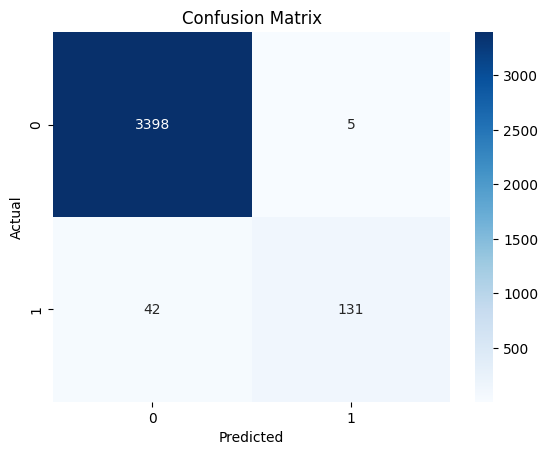

ROC-AUC SCORE: 0.9783580961375461


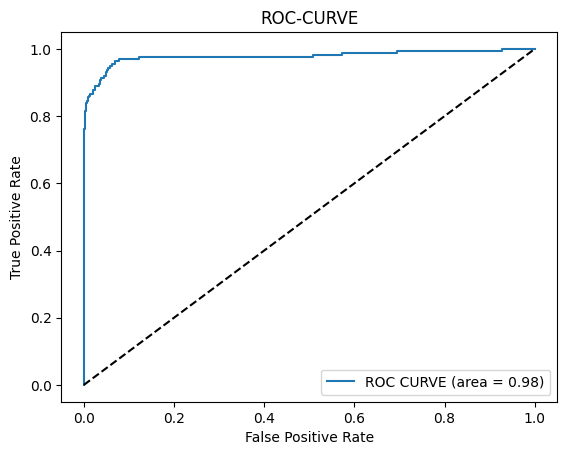

In [37]:
y_val_pred=best_model_grid.predict(x_val)
y_val_proba=best_model_grid.decision_function(x_val)

print("Classification Report:\n",classification_report(y_val,y_val_pred))

cm=confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, fmt='d', annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

roc_auc=roc_auc_score(y_val,y_val_proba)
print("ROC-AUC SCORE:",roc_auc)

fpr,tpr,_=roc_curve(y_val,y_val_proba)
plt.plot(fpr, tpr, label=f'ROC CURVE (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-CURVE')
plt.legend()
plt.show()


**PREDICTION AND DEPLOYMENT**

In [38]:
import pickle

In [39]:
with open("/content/drive/MyDrive/best_model.pkl","wb") as f:
  pickle.dump(best_model_grid,f)
with open("/content/drive/MyDrive/tfidf_vectorizer.pkl","wb") as f:
  pickle.dump(tfidf,f)


In [3]:
!pip install flask flask-ngrok lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0e40a8f151780273cad5dbd9e40c667d44585ba954da561c5af34fd2a13eee9b
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [13]:
from flask import Flask,request,jsonify
from flask_ngrok import run_with_ngrok
import pickle
from lime.lime_text import LimeTextExplainer

with open("/content/drive/MyDrive/best_model.pkl","rb") as f:
    model = pickle.load(f)

with open("/content/drive/MyDrive/tfidf_vectorizer.pkl","rb") as f:
    vectorizer = pickle.load(f)


app = Flask(__name__)


def predict_proba_wrapper(texts):
    if isinstance(texts, str):
        texts = [texts]
    X = vectorizer.transform(texts)
    return model.predict_proba(X)

@app.route('/predict', methods=["POST"])
def predict():
    data = request.get_json()
    if not data or 'description' not in data:
        return jsonify({"error": "Missing 'description' in request"}), 400

    job_text = data['description']
    X = vectorizer.transform([job_text])
    prediction = model.predict(X)[0]
    proba = model.predict_proba(X)[0].tolist()

    return jsonify({
        "prediction": prediction,
        "probabilities": {
            "Real": proba[0],
            "Fake": proba[1]
        }
    })


@app.route("/explain", methods=["POST"])
def explain():
    data = request.get_json()
    if not data or 'description' not in data:
        return jsonify({"error": "Missing 'description' in request"}), 400

    job_text = data['description']
    explainer = LimeTextExplainer(class_names=["Real", "Fake"])
    exp = explainer.explain_instance(job_text, predict_proba_wrapper, num_features=6)

    return jsonify({"Explanation": exp.as_list()})

if __name__=="__main__":
    run_with_ngrok(app)
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-8:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            